In [1]:
from pykawa.cross_sections import CrossSection
from pykawa.utils import get_phases
import numpy as np
import matplotlib.pyplot as plt

### pykawa

This repository stores solutions for the phase shifts as a function of velocity for attractive and repulsive Yukawa potentials. For a Yukawa potential of the form

$$V(r) = \pm \frac{\alpha_\chi}{r} e^{-m_\phi r}$$

where $\alpha_\chi$ is the coupling constant and $m_\phi$ is the mediator mass. The radial Schrödinger equation for each partial wave $\ell$ is solved exactly, followed the variable phase method, to obtain the phase shifts $\delta_\ell(v)$. The phase shifts are then summed to obtain the cross section as a function of velocity. 

The precomputed phase shifts are parameterized by $\log_{10}(m_\chi / m_\phi)$ and $\log_{10}(\alpha_\chi)$ for $v$ spanning $\sim 1 - 1000 \rm{km} \ \rm{s^{-1}}$. These are stored as compressed `.npz` archives for efficient lookup and interpolation.

### Example usage for a single cross section

The repulsive cross sections are computed for $\log_{10} \alpha_{\chi} \in \left[-4.4, -2.0\right]$ and $\log_{10} m_{\chi} / m_{\phi} \in \left[2.8,5.2\right]$. The overall normalization of the cross section is a free parameter. Note that once you choose an overall normalization (throuh the "amp_at_vref" parameter, for a given reference velocity v_ref"), you effecitvely also choose $m_{\chi}$. 

The CrossSection class can be initialized from the phase shifts and certain angular average. In this case, we use the "VISCOSITY" transfer cross section, which is most relevant for structure formation. The class has a call method, which automatically performs a spline interpolation. 

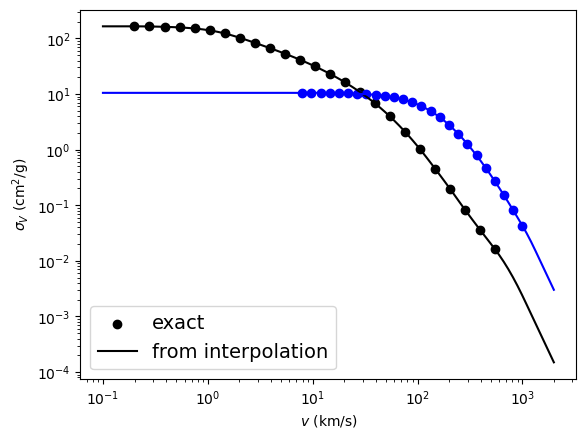

In [2]:
fig = plt.figure(1)
ax = plt.subplot(111)
v_extended = np.logspace(-1, 3.3, 100)

# A model in the semi-classical regime (many partial waves contribute)
log10_mass_ratio = 5.0
log10_alpha = -2.9
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)

amp_at_vref = 10
vref = 30
sigma_exact = cross(10**log10_velocity, amp_at_vref, vref)
sigma_interp = cross(v_extended, amp_at_vref, vref)
ax.scatter(10**log10_velocity, sigma_exact, label='exact', color='k')
ax.plot(v_extended, sigma_interp, label='from interpolation', color='k')

# A model in the Born regime (very few partial waves contribute, analytic solutions available)
log10_mass_ratio = 3.4
log10_alpha = -3.8
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)

v_extended = np.logspace(-1, 3.3, 100)

amp_at_vref = 10
vref = 30
sigma_exact = cross(10**log10_velocity, amp_at_vref, vref)
sigma_interp = cross(v_extended, amp_at_vref, vref)
ax.scatter(10**log10_velocity, sigma_exact, color='b')
ax.plot(v_extended, sigma_interp, color='b')

ax.legend(fontsize=14)
ax.set_xlabel(r'$v$ (km/s)')
ax.set_ylabel(r'$\sigma_V$ (cm$^2$/g)')
ax.set_xscale('log')
ax.set_yscale('log')

plt.show()

### Particle physis parameters

Given the coupling strength, the ratio $m_{\chi} / m_{\phi}$, and values for amp_at_vref and vref, one can get the particle physics parameters $m_{\chi}, m_{\phi}, $\alpha_{\chi}$ as follows

In [3]:
log10_mass_ratio = 5.0
log10_alpha = -2.9
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)

amp_at_vref = 10
v_ref = 30
params = cross.particle_physics_params(amp_at_vref, v_ref)
print('m_chi [GeV]: ', params['m_chi'])
print('m_phi [MeV]: ', 1000 * params['m_phi'])
print('alpha_chi: ', params['alpha_chi'])
print('\n')
log10_mass_ratio = 3.4
log10_alpha = -3.8
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)

amp_at_vref = 10
v_ref = 30
params = cross.particle_physics_params(amp_at_vref, v_ref)
print('m_chi [GeV]: ', params['m_chi'])
print('m_phi [MeV]: ', 1000 * params['m_phi'])
print('alpha_chi: ', params['alpha_chi'])

m_chi [GeV]:  125.4151309820496
m_phi [MeV]:  1.2541513098204962
alpha_chi:  0.0012589254117941675


m_chi [GeV]:  4.96331854069502
m_phi [MeV]:  1.975932700791808
alpha_chi:  0.00015848931924611142


### Example usage for an attractive cross section

As with the repulsive case, the overall normalization of the cross section is a free parameter set through the `amp_at_vref` parameter at a chosen reference velocity `v_ref`. 

The attractive cross sections are computed for $\log_{10} \alpha_{\chi} \in \left[-4.6, -2.6\right]$ and $\log_{10} m_{\chi} / m_{\phi} \in \left[3.5, 4.7\right]$. The attractive potential has resonant features at low velocities, leading to a more complex velocity dependence than the repulsive case. The solutions and velocity sampling are done on a much denser grid to capture these features. 

m_chi [GeV]:  14.527865988148386
m_phi [MeV]:  2.4671856198187863
alpha_chi:  0.001995262314968879


m_chi [GeV]:  62.3339740364145
m_phi [MeV]:  2.4815602032992117
alpha_chi:  0.001584893192461114




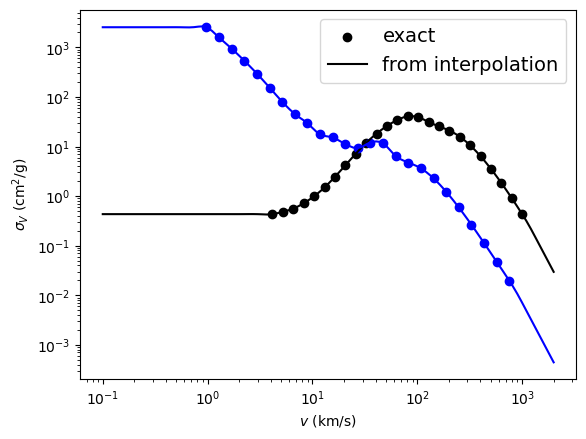

In [4]:
fig = plt.figure(1)
ax = plt.subplot(111)
v_extended = np.logspace(-1, 3.3, 100)

# A model in the resonant regime (strong velocity dependence at low v)
log10_mass_ratio = 3.77
log10_alpha = -2.7
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'ATTRACTIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)
amp_at_vref = 10
vref = 30
sigma_exact = cross(10**log10_velocity, amp_at_vref, vref)
sigma_interp = cross(v_extended, amp_at_vref, vref)
ax.scatter(10**log10_velocity, sigma_exact, label='exact', color='k')
ax.plot(v_extended, sigma_interp, label='from interpolation', color='k')
params = cross.particle_physics_params(amp_at_vref, v_ref)
print('m_chi [GeV]: ', params['m_chi'])
print('m_phi [MeV]: ', 1000 * params['m_phi'])
print('alpha_chi: ', params['alpha_chi'])
print('\n')

# A model in the resonant regime (strong velocity dependence at low v)
log10_mass_ratio = 4.4
log10_alpha = -2.8
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'ATTRACTIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)
amp_at_vref = 10
vref = 30
sigma_exact = cross(10**log10_velocity, amp_at_vref, vref)
sigma_interp = cross(v_extended, amp_at_vref, vref)
ax.scatter(10**log10_velocity, sigma_exact, color='b')
ax.plot(v_extended, sigma_interp, color='b')
params = cross.particle_physics_params(amp_at_vref, v_ref)
print('m_chi [GeV]: ', params['m_chi'])
print('m_phi [MeV]: ', 1000 * params['m_phi'])
print('alpha_chi: ', params['alpha_chi'])
print('\n')

ax.legend(fontsize=14)
ax.set_xlabel(r'$v$ (km/s)')
ax.set_ylabel(r'$\sigma_V$ (cm$^2$/g)')
ax.set_xscale('log')
ax.set_yscale('log')
plt.show()

### Thermal averages

For structure formation, the relevant quantity is a thermal average of the velocity-dependent cross section. For a dark matter halo consistenting of dark matter particles obeying Maxwell-Boltzmann statistics, we can define an effective cross section strength at a velocity scale $v_0$ as

$$\langle \sigma_V \rangle (v_0) = \frac{\int_0^\infty \sigma_V(v) \, v^7 \, e^{-v^2/4v_0^2} \, dv}{\int_0^\infty v^7 \, e^{-v^2/4v_0^2} \, dv}$$

$v_0$ depends on the halo mass: $v_0 = 0.64 v_{\rm{max}}\left(m_{200}\right)$. The `CrossSection` class provides a `thermal_average` method that evaluates this integral numerically for a given $v_0$ and overall normalization `amp_at_vref`.

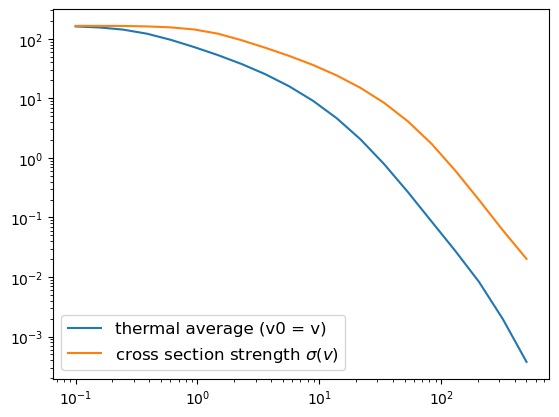

In [13]:
log10_mass_ratio = 5.0
log10_alpha = -2.9
angular_average = 'VISCOSITY'
log10_velocity, phases = get_phases(log10_mass_ratio, log10_alpha, 'REPULSIVE_YUKAWA')
cross = CrossSection.from_phase_shifts(
    log10_velocity, phases, angular_average, log10_alpha, log10_mass_ratio
)
amp_at_vref = 10
v_ref = 30
v0 = np.logspace(-1, 2.7, 20)
sigma_v=[]
for v0i in v0:
    sigma_v.append(cross.thermal_average(v0i, amp_at_vref, v_ref))

plt.loglog(v0, sigma_v, label='thermal average (v0 = v)')
plt.loglog(v0, cross(v0, amp_at_vref, v_ref), label='cross section strength '+r'$\sigma\left(v\right)$')
plt.legend(fontsize=12)